# Training history comparison: datasets A and B (fixed N = 8)

Compare six PPO training logs: datasets A and B, each trained with maximum episode lengths of 30, 45, and 60 steps. The notebook compares logged training metrics with reproducible equiprobable-random-action reference rollouts; it does not evaluate trained checkpoints.

## Load the training logs

Load the six logged arrays directly: one run for each dataset and episode-length combination (30, 45, and 60 steps).

In [1]:
import sys
from pathlib import Path

import numpy as np
import json
import pandas as pd

project_root = Path.cwd().resolve()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise FileNotFoundError('Could not find the src folder.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from src.env import DynkinEnv

run_specs = {
    f"Dataset {dataset} — {episode_steps} episode steps": {
        "dataset": dataset,
        "episode_steps": episode_steps,
        "path": project_root / "results" / directory / "train_log.npz",
    }
    for dataset, directories in {
        "A": {
            30: "A_seed0_Nfixed8",
            45: "A_seed0_steps45_Nfixed8",
            60: "A_seed0_steps60_Nfixed8",
        },
        "B": {
            30: "B_seed0_Nfixed8",
            45: "B_seed0_steps45_Nfixed8",
            60: "B_seed0_steps60_Nfixed8",
        },
    }.items()
    for episode_steps, directory in directories.items()
}

histories = {}
for name, spec in run_specs.items():
    path = spec["path"]
    if not path.exists():
        raise FileNotFoundError(f"Missing training log for {name}: {path}")
    with np.load(path) as data:
        histories[name] = {key: data[key] for key in data.files}

print(f"Project root: {project_root}")
print(f"Loaded {len(histories)} training logs:")
for name in histories:
    print(f"  {name}")

Project root: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds
Loaded 6 training logs:
  Dataset A — 30 episode steps
  Dataset A — 45 episode steps
  Dataset A — 60 episode steps
  Dataset B — 30 episode steps
  Dataset B — 45 episode steps
  Dataset B — 60 episode steps


## Summary statistics and comparison

The table shows the first, final, and best logged values, plus the first-to-final change. Success-rate statistics ignore `NaN` entries, which occur when no episodes finish in an update.

In [2]:
import pandas as pd

summary_rows = []
for dataset, history in histories.items():
    success = history["success_rate"]
    success = success[np.isfinite(success)]
    summary_rows.append({
        "dataset": dataset,
        "updates": len(history["timesteps"]),
        "final_timesteps": int(history["timesteps"][-1]),
        "reward_first": history["reward"][0],
        "reward_final": history["reward"][-1],
        "reward_best": history["reward"].max(),
        "margin_first": history["margin"][0],
        "margin_final": history["margin"][-1],
        "margin_best": history["margin"].max(),
        "success_first": success[0] if len(success) else np.nan,
        "success_final": success[-1] if len(success) else np.nan,
        "success_best": success.max() if len(success) else np.nan,
    })

summary = pd.DataFrame(summary_rows).set_index("dataset")
display(summary.style.format({
    "reward_first": "{:+.3f}", "reward_final": "{:+.3f}", "reward_best": "{:+.3f}",
    "margin_first": "{:+.3f}", "margin_final": "{:+.3f}", "margin_best": "{:+.3f}",
    "success_first": "{:.1%}", "success_final": "{:.1%}", "success_best": "{:.1%}",
}, na_rep="—"))

for dataset, history in histories.items():
    success = history["success_rate"]
    success = success[np.isfinite(success)]
    if len(success):
        print(
            f"{dataset}: reward {history['reward'][0]:+.3f} -> {history['reward'][-1]:+.3f}; "
            f"margin {history['margin'][0]:+.3f} -> {history['margin'][-1]:+.3f}; "
            f"success rate {success[0]:.1%} -> {success[-1]:.1%}."
        )
    else:
        print(f"{dataset}: no finite success-rate values were logged.")

same_horizon = (
    summary["final_timesteps"].nunique() == 1 and summary["updates"].nunique() == 1
)
print(f"Same logged horizon and update count: {same_horizon}")

,updates,final_timesteps,reward_first,reward_final,reward_best,margin_first,margin_final,margin_best,success_first,success_final,success_best
dataset,,,,,,,,,,,
Dataset A — 30 episode steps,1953,1999872,-1.000,-1.000,-1.000,-5.766,-7.998,-5.374,0.0%,0.0%,0.0%
Dataset A — 45 episode steps,1953,1999872,-1.000,-1.000,-1.000,-5.846,-9.096,-5.467,0.0%,0.0%,0.0%
Dataset A — 60 episode steps,1953,1999872,-1.000,-1.000,-1.000,-5.902,-8.992,-5.364,0.0%,0.0%,0.0%
Dataset B — 30 episode steps,1953,1999872,-0.965,-0.990,-0.946,-3.173,-5.228,-2.794,0.0%,2.8%,14.6%
Dataset B — 45 episode steps,1953,1999872,-0.973,-0.994,-0.952,-3.557,-5.420,-3.172,0.0%,0.0%,16.0%
Dataset B — 60 episode steps,1953,1999872,-0.984,-0.992,-0.956,-4.132,-8.401,-3.651,0.0%,5.6%,15.8%


Dataset A — 30 episode steps: reward -1.000 -> -1.000; margin -5.766 -> -7.998; success rate 0.0% -> 0.0%.
Dataset A — 45 episode steps: reward -1.000 -> -1.000; margin -5.846 -> -9.096; success rate 0.0% -> 0.0%.
Dataset A — 60 episode steps: reward -1.000 -> -1.000; margin -5.902 -> -8.992; success rate 0.0% -> 0.0%.
Dataset B — 30 episode steps: reward -0.965 -> -0.990; margin -3.173 -> -5.228; success rate 0.0% -> 2.8%.
Dataset B — 45 episode steps: reward -0.973 -> -0.994; margin -3.557 -> -5.420; success rate 0.0% -> 0.0%.
Dataset B — 60 episode steps: reward -0.984 -> -0.992; margin -4.132 -> -8.401; success rate 0.0% -> 5.6%.
Same logged horizon and update count: True


## Training curves and mean-margin note

The three plots are shown side by side, with all six training histories and no smoothing. The margin calculation below reports the share of updates whose batch-mean margin is positive.

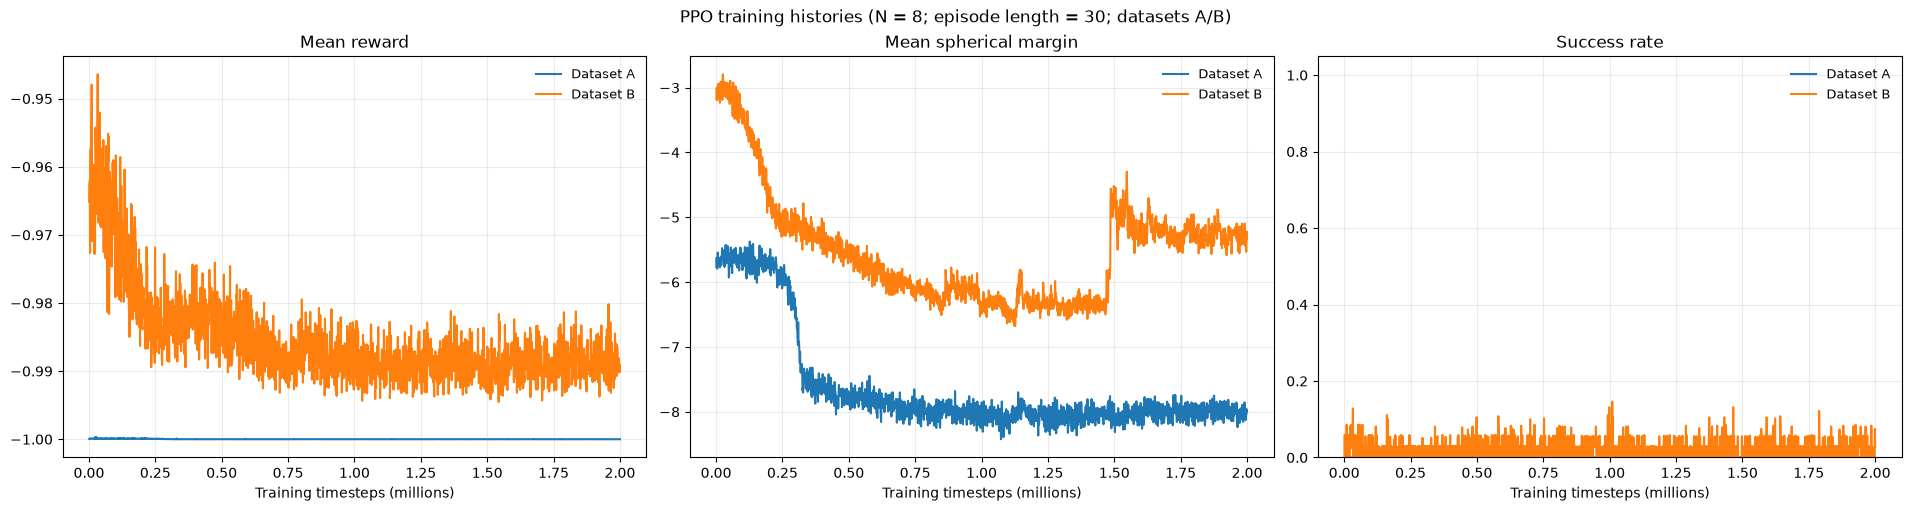

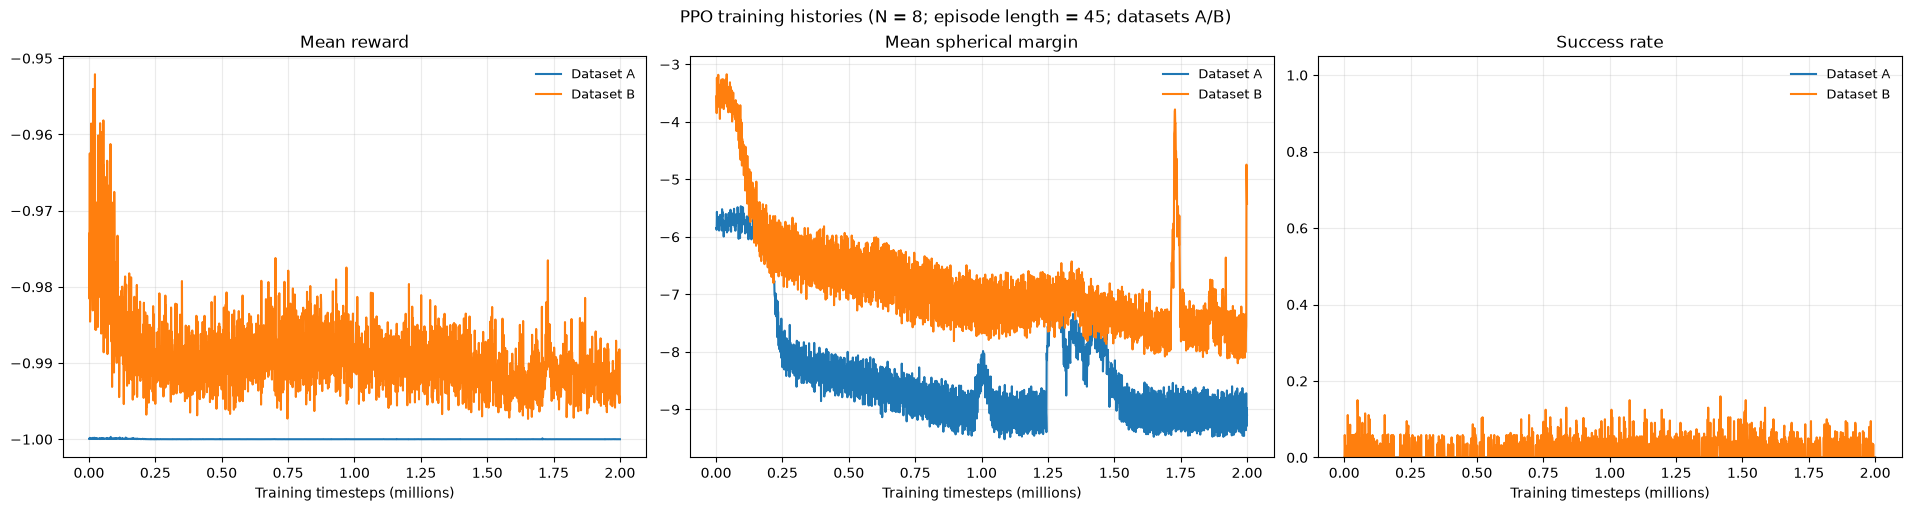

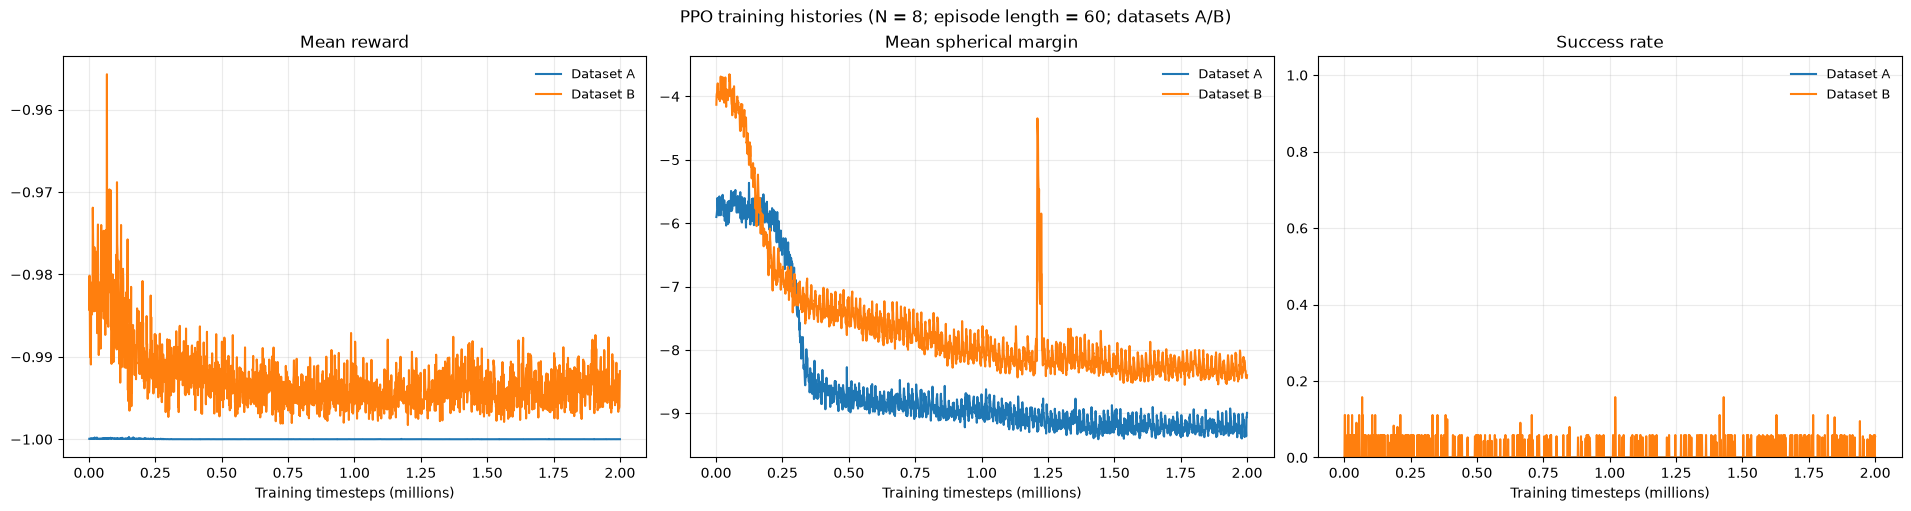

Dataset A — 30 episode steps: 0.0% of updates have a positive mean margin; overall mean = -7.627.
Dataset B — 30 episode steps: 0.0% of updates have a positive mean margin; overall mean = -5.519.
Dataset A — 45 episode steps: 0.0% of updates have a positive mean margin; overall mean = -8.346.
Dataset B — 45 episode steps: 0.0% of updates have a positive mean margin; overall mean = -6.780.
Dataset A — 60 episode steps: 0.0% of updates have a positive mean margin; overall mean = -8.533.
Dataset B — 60 episode steps: 0.0% of updates have a positive mean margin; overall mean = -7.568.
This is the fraction of updates with a positive batch-mean margin, not the fraction of individual states with positive margin. A few large positive values can outweigh many smaller negative values.


In [6]:
import matplotlib.pyplot as plt

# Keep dataset colors consistent across all three episode-length figures.
dataset_colors = {
    "A": plt.get_cmap("tab10")(0),
    "B": plt.get_cmap("tab10")(1),
}

for episode_steps in (30, 45, 60):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)

    for dataset_code in ("A", "B"):
        run_name = f"Dataset {dataset_code} — {episode_steps} episode steps"
        history = histories[run_name]
        x = history["timesteps"] / 1_000_000
        color = dataset_colors[dataset_code]

        axes[0].plot(x, history["reward"], label=f"Dataset {dataset_code}", color=color, linewidth=1.5)
        axes[1].plot(x, history["margin"], label=f"Dataset {dataset_code}", color=color, linewidth=1.5)
        axes[2].plot(x, history["success_rate"], label=f"Dataset {dataset_code}", color=color, linewidth=1.5)

    for ax in axes:
        ax.set_xlabel("Training timesteps (millions)")
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=9)

    axes[0].set_title("Mean reward")
    axes[1].set_title("Mean spherical margin")
    axes[2].set_title("Success rate")
    axes[2].set_ylim(0, 1.05)
    fig.suptitle(f"PPO training histories (N = 8; episode length = {episode_steps}; datasets A/B)")
    plt.show()

for episode_steps in (30, 45, 60):
    for dataset_code in ("A", "B"):
        run_name = f"Dataset {dataset_code} — {episode_steps} episode steps"
        margin = histories[run_name]["margin"]
        positive_fraction = np.mean(margin > 0)
        print(f"{run_name}: {positive_fraction:.1%} of updates have a positive mean margin; "
              f"overall mean = {margin.mean():+.3f}.")

print("This is the fraction of updates with a positive batch-mean margin, "
      "not the fraction of individual states with positive margin. A few large "
      "positive values can outweigh many smaller negative values.")

## Equiprobable random-action baselines

Generate 1,000 independent random-action episodes for each of the six dataset/episode-length combinations at fixed N = 8. Each baseline uses the matching maximum episode length (30, 45, or 60 steps); actions are sampled uniformly from the environment's 112-action space. Raw transition margins and per-episode outcomes are saved under `results/`. The random baseline curves below are overall mean-margin references, not time-varying training histories.

In [4]:
N_EPISODES = 1_000
BASELINE_SEED = 2026

results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)
baseline_rows = []
baseline_episode_summaries = []

for run_index, (run_name, spec) in enumerate(run_specs.items()):
    dataset_code = spec["dataset"]
    max_episode_steps = spec["episode_steps"]
    env_seed = BASELINE_SEED + run_index
    action_seed = BASELINE_SEED + 100 + run_index
    env = DynkinEnv(
        n=8,
        max_steps=max_episode_steps,
        dataset=dataset_code,
        seed=env_seed,
    )
    action_rng = np.random.default_rng(action_seed)

    for episode in range(N_EPISODES):
        env.reset()
        episode_rows = []
        episode_success = False

        for step in range(1, max_episode_steps + 1):
            action = int(action_rng.integers(0, env.action_dim))
            _, _, terminated, truncated, info = env.step(action)
            episode_rows.append({
                "run": run_name,
                "dataset": dataset_code,
                "max_episode_steps": max_episode_steps,
                "episode": episode,
                "step": step,
                "action": action,
                "margin": info.margin,
            })
            if terminated or truncated:
                episode_success = bool(info.success)
                break

        for row in episode_rows:
            row["episode_success"] = episode_success
            baseline_rows.append(row)
        baseline_episode_summaries.append({
            "run": run_name,
            "dataset": dataset_code,
            "max_episode_steps": max_episode_steps,
            "episode": episode,
            "steps": len(episode_rows),
            "success": episode_success,
        })

del env
baseline_data = pd.DataFrame(baseline_rows)
baseline_episodes = pd.DataFrame(baseline_episode_summaries)

baseline_csv_path = results_dir / "random_baseline_Nfixed8_steps30_45_60.csv"
baseline_metadata_path = results_dir / "random_baseline_Nfixed8_steps30_45_60.json"
baseline_data.to_csv(baseline_csv_path, index=False)

baseline_metadata = {
    "n": 8,
    "episodes_per_run": N_EPISODES,
    "run_configurations": [
        {
            "run": run_name,
            "dataset": spec["dataset"],
            "max_episode_steps": spec["episode_steps"],
            "training_log": str(spec["path"].relative_to(project_root)),
        }
        for run_name, spec in run_specs.items()
    ],
    "action_dim": 112,
    "action_sampling": "uniform integer action in [0, action_dim)",
    "env_seeds": {
        run_name: BASELINE_SEED + index
        for index, run_name in enumerate(run_specs)
    },
    "action_rng_seeds": {
        run_name: BASELINE_SEED + 100 + index
        for index, run_name in enumerate(run_specs)
    },
    "margin": "raw per-transition spherical margin from StepInfo.margin",
    "success": "episode_success is repeated on each transition row for its episode",
}
baseline_metadata_path.write_text(json.dumps(baseline_metadata, indent=2), encoding="utf-8")

baseline_summary = baseline_data.groupby("run").agg(
    transitions=("margin", "size"),
    mean_margin=("margin", "mean"),
    max_margin=("margin", "max"),
)
baseline_episode_summary = baseline_episodes.groupby("run").agg(
    episodes=("episode", "size"),
    successes=("success", "sum"),
    success_rate=("success", "mean"),
)
baseline_summary = baseline_summary.join(baseline_episode_summary)
display(baseline_summary.style.format({
    "mean_margin": "{:+.3f}",
    "max_margin": "{:+.3f}",
    "success_rate": "{:.1%}",
}))
print(f"Saved transition records: {baseline_csv_path}")
print(f"Saved run configuration: {baseline_metadata_path}")

,transitions,mean_margin,max_margin,episodes,successes,success_rate
run,,,,,,
Dataset A — 30 episode steps,30000,-5.524,-2.536,1000,0,0.0%
Dataset A — 45 episode steps,45000,-5.537,-1.379,1000,0,0.0%
Dataset A — 60 episode steps,60000,-5.528,-2.540,1000,0,0.0%
Dataset B — 30 episode steps,29476,-2.973,+0.586,1000,19,1.9%
Dataset B — 45 episode steps,44138,-3.465,+1.000,1000,20,2.0%
Dataset B — 60 episode steps,59057,-3.824,+1.000,1000,16,1.6%


Saved transition records: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results\random_baseline_Nfixed8_steps30_45_60.csv
Saved run configuration: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results\random_baseline_Nfixed8_steps30_45_60.json


## Smoothed PPO margins and six random-action references

PPO margins are smoothed with a trailing moving average (50 updates by default). Each of the six random baselines is shown as its overall per-transition mean across the corresponding training run's full timestep range; the horizontal lines are constant references, not training trajectories. The shared x-axis is actual environment timesteps.

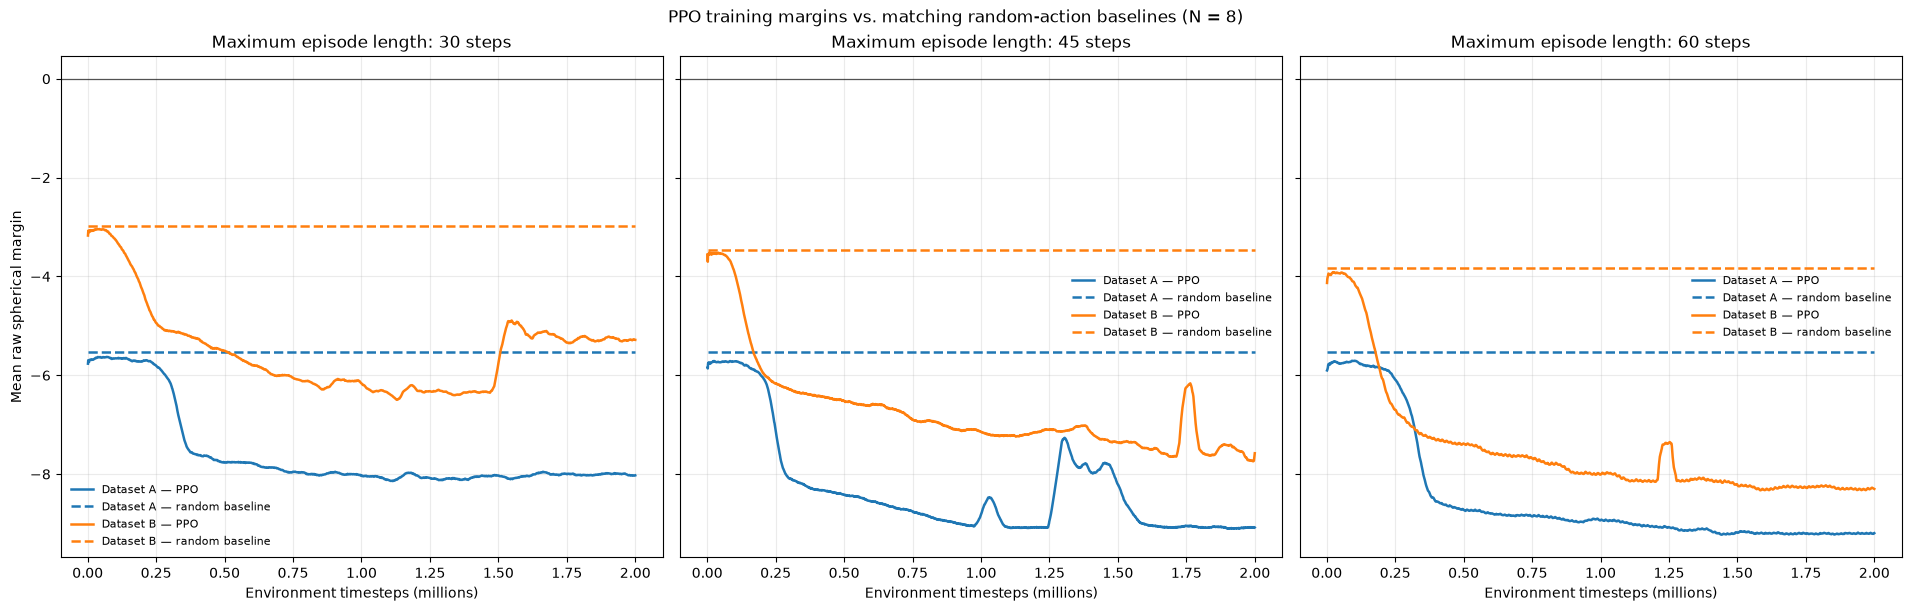

PPO smoothing: trailing window of 50 updates; each dashed line is the overall mean across that run's saved random-baseline transitions.


In [7]:
MOVING_AVERAGE_UPDATES = 50

episode_lengths = (30, 45, 60)
fig, axes = plt.subplots(
    1,
    len(episode_lengths),
    figsize=(19, 6),
    sharey=True,
    constrained_layout=True,
)
random_means = baseline_data.groupby("run")["margin"].mean()

for ax, episode_steps in zip(axes, episode_lengths):
    for dataset_code in ("A", "B"):
        run_name = f"Dataset {dataset_code} — {episode_steps} episode steps"
        history = histories[run_name]
        timesteps = history["timesteps"]
        margin = pd.Series(history["margin"])
        smoothed_margin = margin.rolling(
            window=MOVING_AVERAGE_UPDATES,
            min_periods=1,
        ).mean()
        color = dataset_colors[dataset_code]

        ax.plot(
            timesteps / 1_000_000,
            smoothed_margin,
            color=color,
            linewidth=1.8,
            label=f"Dataset {dataset_code} — PPO",
        )
        baseline_mean = float(random_means[run_name])
        ax.plot(
            [timesteps[0] / 1_000_000, timesteps[-1] / 1_000_000],
            [baseline_mean, baseline_mean],
            color=color,
            linestyle="--",
            linewidth=1.8,
            label=f"Dataset {dataset_code} — random baseline",
        )

    ax.axhline(0, color="black", linewidth=0.9, alpha=0.65)
    ax.set_title(f"Maximum episode length: {episode_steps} steps")
    ax.set_xlabel("Environment timesteps (millions)")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, loc="best")

axes[0].set_ylabel("Mean raw spherical margin")
fig.suptitle("PPO training margins vs. matching random-action baselines (N = 8)")
plt.show()

print(
    f"PPO smoothing: trailing window of {MOVING_AVERAGE_UPDATES} updates; "
    "each dashed line is the overall mean across that run's saved random-baseline transitions."
)